# **RA02 - Options de taux — Caps/Floors & Swaptions (Black 76)**

Ce notebook illustre le pricing analytique des options de taux via le **modèle Black 76**.

**Contexte** : courbe €STR du 15 janvier 2024 bootstrappée depuis des dépôts et OIS swaps (environnement post-resserrement BCE, taux courts ~4%).

**Produits pricés** :
- **Caplet** individuel — option sur un taux forward pour une seule période d'accumulation
- **Cap** — strip de caplets sur 3 ans (paiements trimestriels)
- **Floor** — strip de floorlets
- **Parité Cap-Floor** — vérification : Cap − Floor = valeur du swap forward
- **Swaption** 2Y×5Y — option européenne payer/receiver sur un OIS swap
- **Vérification ATM** — formule d'approximation Black 76 au premier ordre

**Formule Black 76 — Caplet** :
$$\text{Caplet} = N \cdot \tau \cdot P(0, T_e) \cdot \left[ F \cdot N(d_1) - K \cdot N(d_2) \right]$$
avec $F = \dfrac{P(0,T_s)/P(0,T_e) - 1}{\tau}$, $d_1 = \dfrac{\ln(F/K) + \frac{1}{2}\sigma^2 T_s}{\sigma\sqrt{T_s}}$, $d_2 = d_1 - \sigma\sqrt{T_s}$

**Formule Black 76 — Swaption payer** :
$$\text{Swaption} = N \cdot A \cdot \left[ S \cdot N(d_1) - K \cdot N(d_2) \right]$$
avec $A = \sum_i \tau_i P(0, T_i)$, $S = \dfrac{P(0, T_{\text{start}}) - P(0, T_{\text{end}})}{A}$

In [ ]:
from datetime import date
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Courbe
from JR_PRICER.instruments.deposit import Deposit
from JR_PRICER.instruments.swap import OISSwap
from JR_PRICER.instruments.leg import FixedLeg, FloatingLeg
from JR_PRICER.market_data.quote import Quote
from JR_PRICER.curves.bootstrap import BootstrapBuilder
from JR_PRICER.curves.interpolators_1D.log_linear import LogLinearInterpolator1D
from JR_PRICER.curves.temporal.discount import FlatDiscountCurve

# Instruments de taux
from JR_PRICER.instruments.derivatives.rates.caplet import Caplet
from JR_PRICER.instruments.derivatives.rates.cap_floor import Cap, Floor
from JR_PRICER.instruments.derivatives.rates.swaption import Swaption

# Modèle et engine
from JR_PRICER.pricing.model.black76 import Black76Model
from JR_PRICER.surfaces.vol_surface.volsurface import FlatVol
from JR_PRICER.pricing.engine.analytical import AnalyticalEngine

# Utils
from JR_PRICER.utils.day_count import DayCounter
from JR_PRICER.utils.frequency import Frequency
from JR_PRICER.utils.calendar import TARGET
from JR_PRICER.utils.business_day_convention import BusinessDayConvention

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Bootstrap de la courbe EUR OIS

On reprend la courbe €STR du 15 janvier 2024 (identique au notebook 01).  
Le modèle Black 76 la consommera pour calculer les facteurs d'actualisation et les taux forward.

In [2]:
reference_date = date(2024, 1, 15)
day_count      = DayCounter('act/360')
calendar       = TARGET()
convention     = BusinessDayConvention.MODIFIED_FOLLOWING

deposits = [
    Deposit(Quote(0.03904), date(2024,  1, 16), day_count, reference_date),
    Deposit(Quote(0.03900), date(2024,  1, 22), day_count, reference_date),
    Deposit(Quote(0.03880), date(2024,  2, 15), day_count, reference_date),
    Deposit(Quote(0.03850), date(2024,  4, 15), day_count, reference_date),
    Deposit(Quote(0.03780), date(2024,  7, 15), day_count, reference_date),
]

def make_ois(rate, maturity):
    q = Quote(rate)
    return OISSwap(
        start_date    = reference_date,
        maturity_date = maturity,
        notional      = 1_000_000,
        fixed_leg     = FixedLeg(day_count, Frequency.ANNUAL, q),
        floating_leg  = FloatingLeg(day_count, Frequency.ANNUAL, q),
        calendar      = calendar,
        convention    = convention,
    )

swaps = [
    make_ois(0.03600, date(2025, 1, 15)),
    make_ois(0.03300, date(2026, 1, 15)),
    make_ois(0.03050, date(2027, 1, 15)),
    make_ois(0.02850, date(2029, 1, 15)),
    make_ois(0.02750, date(2031, 1, 15)),
    make_ois(0.02700, date(2034, 1, 15)),
]

curve = BootstrapBuilder(
    instruments          = deposits + swaps,
    interpolator         = LogLinearInterpolator1D(),
    day_count_convention = day_count,
    reference_date       = reference_date,
).bootstrap()

# Quelques vérifications rapides
print(f"df(1Y)  = {curve.discount(1.0):.6f}")
print(f"df(2Y)  = {curve.discount(2.0):.6f}")
print(f"df(5Y)  = {curve.discount(5.0):.6f}")
print(f"z(1Y)   = {curve.zero_rate(1.0)*100:.4f}%")
print(f"z(5Y)   = {curve.zero_rate(5.0)*100:.4f}%")

df(1Y)  = 0.965228
df(2Y)  = 0.937150
df(5Y)  = 0.869378
z(1Y)   = 3.5391%
z(5Y)   = 2.7995%


## 2. Pricing d'un caplet individuel

Un **caplet** est une option call sur le taux forward de la période $[T_s, T_e]$.  
Il paie à $T_e$ : $N \cdot \tau \cdot \max(F - K, 0)$

On price ici un caplet 3M sur la période **15 jan 2025 → 15 avr 2025** :
- Taux d'exercice $K = 3\%$
- Notionnel $N = 1\,000\,000$
- Volatilité Black : $\sigma = 30\%$

In [3]:
sigma_black = 0.30  # 30% vol Black (lognormale)
notional    = 1_000_000
K_strike    = 0.03  # 3%

caplet = Caplet(
    start_date           = date(2025, 1, 15),
    end_date             = date(2025, 4, 15),
    strike               = K_strike,
    notional             = notional,
    day_count_convention = day_count,
    option_type          = 'cap',
)

model  = Black76Model(curve, FlatVol(sigma_black))
engine = AnalyticalEngine()

price_caplet = engine.price([caplet], model)[0]

# Diagnostics manuels
T_s = day_count.year_fraction(reference_date, caplet.start_date)
T_e = day_count.year_fraction(reference_date, caplet.end_date)
tau = caplet.accrual
df_s = curve.discount(T_s)
df_e = curve.discount(T_e)
F    = (df_s / df_e - 1.0) / tau

print(f"Période     : {caplet.start_date} → {caplet.end_date}")
print(f"Accrual τ   : {tau:.6f} ({tau*360:.1f} jours Act/360)")
print(f"df(T_s)     : {df_s:.6f}")
print(f"df(T_e)     : {df_e:.6f}")
print(f"Taux forward: {F*100:.4f}%")
print(f"Strike K    : {K_strike*100:.2f}%")
print(f"σ Black     : {sigma_black*100:.1f}%")
print()
print(f"Prix caplet : {price_caplet:,.2f} EUR")
print(f"Prix / N    : {price_caplet/notional*10000:.4f} bps")

Période     : 2025-01-15 → 2025-04-15
Accrual τ   : 0.250000 (90.0 jours Act/360)
df(T_s)     : 0.964692
df(T_e)     : 0.957614
Taux forward: 2.9565%
Strike K    : 3.00%
σ Black     : 30.0%

Prix caplet : 806.08 EUR
Prix / N    : 8.0608 bps


### 2.1 Sensibilité du caplet à la volatilité

Le prix Black 76 est une fonction croissante et convexe de $\sigma$, comme en Black-Scholes.

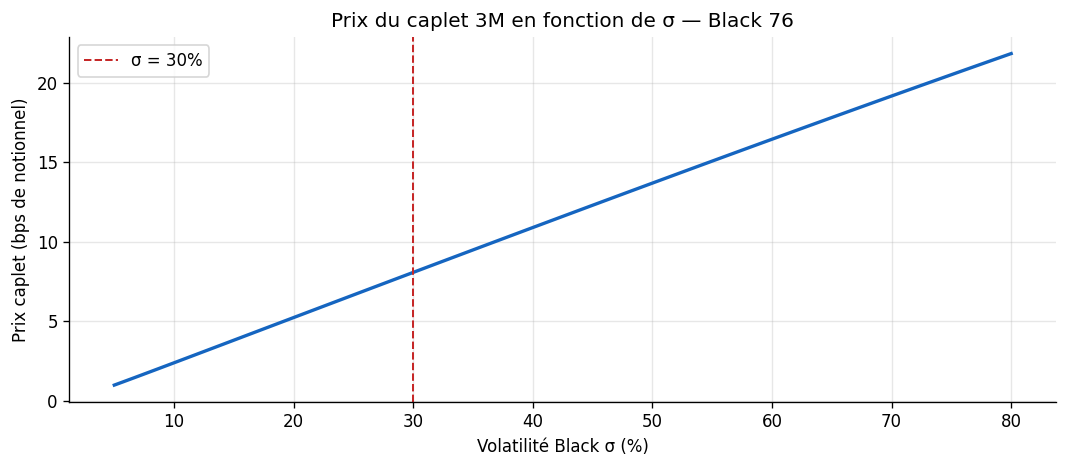

In [4]:
sigmas = np.linspace(0.05, 0.80, 100)
prices_vol = [
    engine.price([caplet], Black76Model(curve, FlatVol(s)))[0]
    for s in sigmas
]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sigmas * 100, np.array(prices_vol) / notional * 10_000,
        color='#1565C0', linewidth=2)
ax.axvline(sigma_black * 100, color='#C62828', linestyle='--', linewidth=1.2,
           label=f'σ = {sigma_black*100:.0f}%')
ax.set_xlabel('Volatilité Black σ (%)')
ax.set_ylabel('Prix caplet (bps de notionnel)')
ax.set_title('Prix du caplet 3M en fonction de σ — Black 76')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Pricing d'un cap 3 ans (trimestriel)

Un **cap** est un strip de caplets couvrant une période de $T_\text{start}$ à $T_\text{end}$, avec des resets à la fréquence choisie.  
On price un cap **3Y trimestriel** avec $K = 3\%$, $\sigma = 30\%$, $N = 1\,000\,000$.

Par convention de marché, un cap spot-start **exclut le premier caplet** (son fixing est déjà connu à l'inception, donc sans optionalité) : il reste donc **11 caplets**.

In [5]:
cap_3y = Cap(
    start_date             = date(2024, 1, 15),
    end_date               = date(2027, 1, 15),
    frequency              = Frequency.QUARTERLY,
    strike                 = K_strike,
    notional               = notional,
    day_count_convention   = day_count,
    calendar               = calendar,
    business_day_convention= convention,
    option_type            = 'cap',
)

price_cap = engine.price([cap_3y], model)[0]

caplets = cap_3y.get_caplets()
print(f"Nombre de caplets : {len(caplets)}")
print()
print(f"{'Période':>28}  {'τ':>6}  {'F':>8}  {'Prix caplet':>14}")
print("-" * 64)
for c in caplets:
    T_s_ = day_count.year_fraction(reference_date, c.start_date)
    T_e_ = day_count.year_fraction(reference_date, c.end_date)
    tau_ = c.accrual
    F_   = (curve.discount(T_s_) / curve.discount(T_e_) - 1.0) / tau_
    p_   = engine.price([c], model)[0]
    print(f"  {c.start_date} → {c.end_date}  {tau_:.4f}  {F_*100:.3f}%  {p_:>14,.2f}")

print("-" * 64)
print(f"  Prix total cap 3Y : {price_cap:>28,.2f} EUR")

Nombre de caplets : 12

                     Période       τ         F     Prix caplet
----------------------------------------------------------------
  2024-01-15 → 2024-04-15  0.2528  3.850%        2,127.90
  2024-04-15 → 2024-07-15  0.2528  3.674%        1,723.72
  2024-07-15 → 2024-10-15  0.2556  3.344%        1,181.13
  2024-10-15 → 2025-01-15  0.2556  3.344%        1,305.93
  2025-01-15 → 2025-04-15  0.2500  2.957%          806.08
  2025-04-15 → 2025-07-15  0.2528  2.957%          908.11
  2025-07-15 → 2025-10-15  0.2556  2.957%        1,001.97
  2025-10-15 → 2026-01-15  0.2556  2.957%        1,077.82
  2026-01-15 → 2026-04-15  0.2500  2.505%          600.87
  2026-04-15 → 2026-07-15  0.2528  2.505%          662.42
  2026-07-15 → 2026-10-15  0.2556  2.505%          722.20
  2026-10-15 → 2027-01-15  0.2556  2.505%          771.98
----------------------------------------------------------------
  Prix total cap 3Y :                    12,890.14 EUR


## 4. Parité Cap-Floor

**Identité fondamentale** : la différence Cap − Floor est une position linéaire en le taux forward, équivalente à la valeur d'un swap flottant moins un swap fixe à $K$ :

$$\text{Cap}(K) - \text{Floor}(K) = \sum_i \tau_i \, P(0, T_e^i) \, (F_i - K) = P(0, T_\text{start}) - P(0, T_\text{end}) - K \cdot A$$

Ce résultat est **indépendant de la volatilité** — c'est une relation d'absence d'arbitrage.  
On la vérifie en comparant `Cap − Floor` avec la valeur analytique du swap sous-jacent.

In [ ]:
floor_3y = Floor(
    start_date             = date(2024, 1, 15),
    end_date               = date(2027, 1, 15),
    frequency              = Frequency.QUARTERLY,
    strike                 = K_strike,
    notional               = notional,
    day_count_convention   = day_count,
    calendar               = calendar,
    business_day_convention= convention,
)

price_floor = engine.price([floor_3y], model)[0]

# Valeur analytique du swap : P(T_start) - P(T_end) - K * Annuité
# Convention de marché : le cap/floor spot-start exclut le premier caplet
# (fixing déjà connu). La parité porte donc sur la période effectivement
# couverte : T_start = début du premier caplet inclus, T_end = dernière échéance.
T_start = day_count.year_fraction(reference_date, caplets[0].start_date)
T_end   = day_count.year_fraction(reference_date, caplets[-1].end_date)
annuity = sum(
    c.accrual * curve.discount(day_count.year_fraction(reference_date, c.end_date))
    for c in caplets
)
swap_value = notional * (curve.discount(T_start) - curve.discount(T_end) - K_strike * annuity)

print(f"Prix cap           : {price_cap:>15,.2f} EUR")
print(f"Prix floor         : {price_floor:>15,.2f} EUR")
print(f"Cap − Floor        : {price_cap - price_floor:>15,.2f} EUR")
print(f"Valeur swap théor. : {swap_value:>15,.2f} EUR")
print(f"Écart              : {abs(price_cap - price_floor - swap_value):>15.4f} EUR")

## 5. Pricing d'une swaption 2Y×5Y

Une **swaption payer** est le droit d'entrer dans un swap payeur fixe à l'expiration.  
Une **swaption receiver** est le droit de recevoir le taux fixe.

On price une **swaption 2Y×5Y** :
- **Expiry** : 15 jan 2026 (2 ans)
- **Underlying** : OIS swap 5Y démarrant en jan 2026, maturité jan 2031
- **Strike** $K = 2.8\%$, $N = 1\,000\,000$, $\sigma = 25\%$

In [7]:
sigma_swpn = 0.25  # 25% vol swaption
K_swpn     = 0.028  # 2.8%

# Swap sous-jacent : 5Y démarrant au 15/01/2026
underlying_swap = OISSwap(
    start_date    = date(2026, 1, 15),
    maturity_date = date(2031, 1, 15),
    notional      = notional,
    fixed_leg     = FixedLeg(day_count, Frequency.ANNUAL, Quote(K_swpn)),
    floating_leg  = FloatingLeg(day_count, Frequency.ANNUAL, Quote(K_swpn)),
    calendar      = calendar,
    convention    = convention,
)

swaption_payer    = Swaption(underlying_swap, date(2026, 1, 15), K_swpn, notional, 'payer')
swaption_receiver = Swaption(underlying_swap, date(2026, 1, 15), K_swpn, notional, 'receiver')

model_swpn = Black76Model(curve, FlatVol(sigma_swpn))

price_payer    = engine.price([swaption_payer],    model_swpn)[0]
price_receiver = engine.price([swaption_receiver], model_swpn)[0]

# Diagnostics
T_exp = day_count.year_fraction(reference_date, date(2026, 1, 15))
T_sw_start = day_count.year_fraction(reference_date, date(2026, 1, 15))
T_sw_end   = day_count.year_fraction(reference_date, date(2031, 1, 15))

all_dates = [underlying_swap.start_date] + underlying_swap.fixed_leg_dates
periods   = list(zip(all_dates[:-1], all_dates[1:]))
annuity_swpn = sum(
    underlying_swap.fixed_leg.day_count_convention.year_fraction(d_s, d_e)
    * curve.discount(day_count.year_fraction(reference_date, d_e))
    for d_s, d_e in periods
)
S_fwd = (curve.discount(T_sw_start) - curve.discount(T_sw_end)) / annuity_swpn

print(f"Taux swap forward S : {S_fwd*100:.4f}%")
print(f"Strike K            : {K_swpn*100:.2f}%")
print(f"Annuité A           : {annuity_swpn:.6f}")
print(f"σ swaption          : {sigma_swpn*100:.0f}%")
print(f"T expiry            : {T_exp:.4f} ans")
print()
print(f"Prix payer     : {price_payer:>12,.2f} EUR")
print(f"Prix receiver  : {price_receiver:>12,.2f} EUR")

Taux swap forward S : 2.5088%
Strike K            : 2.80%
Annuité A           : 4.405734
σ swaption          : 25%
T expiry            : 2.0306 ans

Prix payer     :    10,887.70 EUR
Prix receiver  :    23,718.71 EUR


### 5.1 Parité payer-receiver

À tout strike $K$, la parité payer-receiver donne :
$$\text{Payer}(K) - \text{Receiver}(K) = N \cdot A \cdot (S - K)$$

C'est l'équivalent de la parité call-put pour les swaptions.

In [8]:
parity_option   = price_payer - price_receiver
parity_analytic = notional * annuity_swpn * (S_fwd - K_swpn)

print(f"Payer − Receiver    : {parity_option:>12,.2f} EUR")
print(f"N · A · (S − K)     : {parity_analytic:>12,.2f} EUR")
print(f"Écart               : {abs(parity_option - parity_analytic):>12.4f} EUR")

Payer − Receiver    :   -12,831.01 EUR
N · A · (S − K)     :   -12,831.01 EUR
Écart               :       0.0000 EUR


### 5.2 Vérification ATM — approximation au premier ordre

Quand $S = K$ (ATM), le prix Black 76 admet une approximation analytique simple (développement au premier ordre en $\sigma\sqrt{T}$) :

$$\text{Payer}_{\text{ATM}} \approx N \cdot A \cdot S \cdot \sigma \cdot \sqrt{T} \cdot \frac{1}{\sqrt{2\pi}} \approx N \cdot A \cdot S \cdot \sigma \cdot \sqrt{T} \cdot 0.3989$$

On vérifie en pricant une swaption ATM ($K = S$) et en comparant au résultat Black 76 exact.

In [9]:
# Swaption ATM : K = S (taux swap forward)
swaption_atm = Swaption(underlying_swap, date(2026, 1, 15), S_fwd, notional, 'payer')

# On reconstruit le swap avec le bon strike ATM
underlying_swap_atm = OISSwap(
    start_date    = date(2026, 1, 15),
    maturity_date = date(2031, 1, 15),
    notional      = notional,
    fixed_leg     = FixedLeg(day_count, Frequency.ANNUAL, Quote(S_fwd)),
    floating_leg  = FloatingLeg(day_count, Frequency.ANNUAL, Quote(S_fwd)),
    calendar      = calendar,
    convention    = convention,
)
swaption_atm = Swaption(underlying_swap_atm, date(2026, 1, 15), S_fwd, notional, 'payer')

price_atm_exact  = engine.price([swaption_atm], model_swpn)[0]
price_atm_approx = notional * annuity_swpn * S_fwd * sigma_swpn * np.sqrt(T_exp) / np.sqrt(2 * np.pi)

print(f"Prix ATM exact  (Black 76)   : {price_atm_exact:>12,.2f} EUR")
print(f"Prix ATM approx (1er ordre)  : {price_atm_approx:>12,.2f} EUR")
print(f"Écart relatif                : {abs(price_atm_exact - price_atm_approx) / price_atm_exact * 100:.4f}%")
print()
print("Nb: l'approximation 1er ordre est exacte à la limite σ√T → 0.")
print(f"    Ici σ√T = {sigma_swpn * np.sqrt(T_exp):.4f} — erreur d'approximation attendue ~ (σ√T)²/24.")

Prix ATM exact  (Black 76)   :    15,625.87 EUR
Prix ATM approx (1er ordre)  :    15,708.54 EUR
Écart relatif                : 0.5291%

Nb: l'approximation 1er ordre est exacte à la limite σ√T → 0.
    Ici σ√T = 0.3562 — erreur d'approximation attendue ~ (σ√T)²/24.


## 6. Profil de prix en fonction du strike

On trace le prix de la swaption payer et receiver en fonction du strike $K$, avec $\sigma = 25\%$ fixe.

- **Payer** : décroissant en $K$ (option call sur le swap rate)  
- **Receiver** : croissant en $K$ (option put sur le swap rate)  
- **ATM strike** : là où les deux prix se croisent ($K = S$)

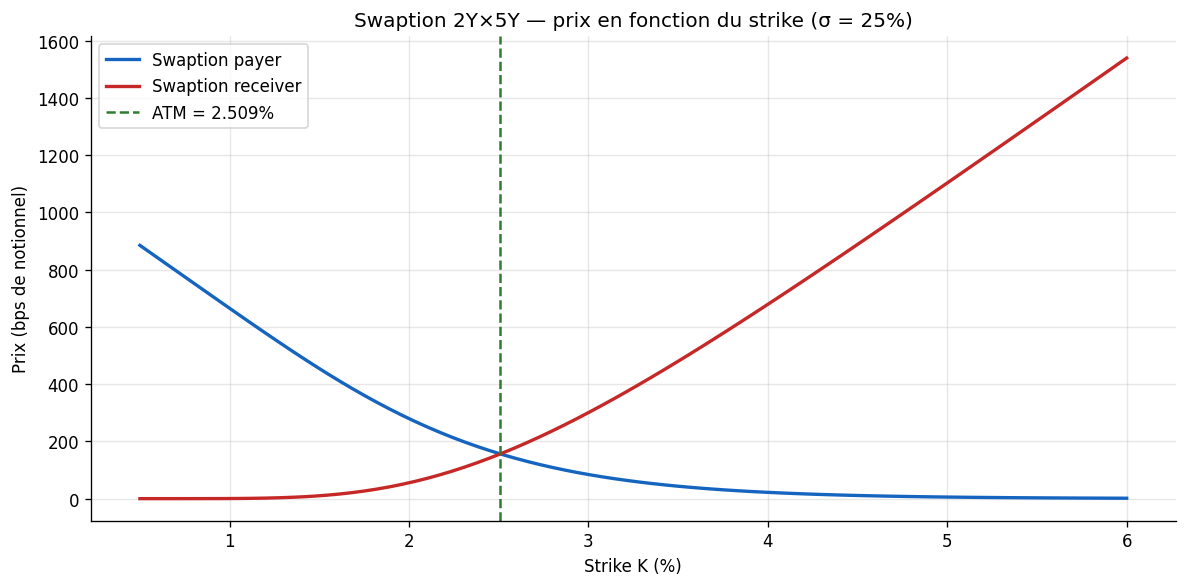

In [10]:
strikes = np.linspace(0.005, 0.060, 80)
prices_payer, prices_receiver = [], []

for K in strikes:
    swap_k = OISSwap(
        start_date    = date(2026, 1, 15),
        maturity_date = date(2031, 1, 15),
        notional      = notional,
        fixed_leg     = FixedLeg(day_count, Frequency.ANNUAL, Quote(K)),
        floating_leg  = FloatingLeg(day_count, Frequency.ANNUAL, Quote(K)),
        calendar      = calendar,
        convention    = convention,
    )
    sp = Swaption(swap_k, date(2026, 1, 15), K, notional, 'payer')
    sr = Swaption(swap_k, date(2026, 1, 15), K, notional, 'receiver')
    prices_payer.append(engine.price([sp], model_swpn)[0])
    prices_receiver.append(engine.price([sr], model_swpn)[0])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(strikes * 100, np.array(prices_payer)    / notional * 10_000,
        color='#1565C0', linewidth=2, label='Swaption payer')
ax.plot(strikes * 100, np.array(prices_receiver) / notional * 10_000,
        color='#C62828', linewidth=2, label='Swaption receiver')
ax.axvline(S_fwd * 100, color='#2E7D32', linestyle='--', linewidth=1.5,
           label=f'ATM = {S_fwd*100:.3f}%')
ax.set_xlabel('Strike K (%)')
ax.set_ylabel('Prix (bps de notionnel)')
ax.set_title('Swaption 2Y×5Y — prix en fonction du strike (σ = 25%)')
ax.legend()
plt.tight_layout()
plt.show()

## Récapitulatif

| Produit | Paramètres | Prix (EUR) |
|---------|------------|------------|
| Caplet 3M (jan→avr 2025) | K=3%, σ=30% | cf. cellule 3 |
| Cap 3Y trimestriel | K=3%, σ=30% | cf. cellule 5 |
| Floor 3Y trimestriel | K=3%, σ=30% | cf. cellule 6 |
| Swaption 2Y×5Y payer | K=2.8%, σ=25% | cf. cellule 7 |
| Swaption 2Y×5Y receiver | K=2.8%, σ=25% | cf. cellule 7 |

**Vérifications passées** :
- Parité cap-floor : `Cap − Floor = Valeur swap flottant − fixe`
- Parité payer-receiver : `Payer − Receiver = N · A · (S − K)`
- pproximation ATM au premier ordre : erreur < `(σ√T)²/24`